In [1]:
from ema_workbench import (
    Model,
    MultiprocessingEvaluator,
    ScalarOutcome,
    IntegerParameter,
    optimize,
    Scenario,
)
from ema_workbench.em_framework.optimization import EpsilonProgress
from ema_workbench.util import ema_logging
from problem_formulation import get_model_for_problem_formulation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
if __name__ == "__main__":
    ema_logging.log_to_stderr(ema_logging.INFO)

    model, steps = get_model_for_problem_formulation(3)
    print(type(model))

    reference_values = {
        "Bmax": 175,
        "Brate": 1.5,
        "pfail": 0.5,
        "discount rate 0": 3.5,
        "discount rate 1": 3.5,
        "discount rate 2": 3.5,
        "ID flood wave shape": 4,
    }
    scen1 = {}

    for key in model.uncertainties:
        name_split = key.name.split("_")

        if len(name_split) == 1:
            scen1.update({key.name: reference_values[key.name]})

        else:
            scen1.update({key.name: reference_values[name_split[1]]})

    ref_scenario = Scenario("reference", **scen1)

<class 'ema_workbench.em_framework.model.Model'>


In [3]:
import random
random.seed(20)

In [4]:
print(model.levers)
print(model.outcomes)

In [5]:
import os
from ema_workbench.em_framework.optimization import ArchiveLogger, EpsilonProgress
from ema_workbench import MultiprocessingEvaluator

# Zorg dat de map bestaat
os.makedirs("./archives", exist_ok=True)

def clean_name(name, prefix="L_"):
    clean = name.replace(" ", "_").replace(".", "_").replace("-", "_")
    if clean[0].isdigit():
        clean = prefix + clean
    return clean

cleaned_lever_names = [clean_name(l.name, "L_") for l in model.levers]
cleaned_outcome_names = [clean_name(o.name, "O_") for o in model.outcomes]


# Verwijder bestaand bestand indien nodig
archive_path = "./archives/optimization.tar.gz"
if os.path.exists(archive_path):
    os.remove(archive_path)

# Convergence metrics
convergence_metrics = [
    ArchiveLogger(
        "./archives",
        cleaned_lever_names,
        cleaned_outcome_names,
        base_filename="optimization.tar.gz",
    ),
    EpsilonProgress(),
]

# Run de optimalisatie
with MultiprocessingEvaluator(model) as evaluator:
    results, convergence = evaluator.optimize(
        nfe=1000,
        searchover='levers',
        convergence=convergence_metrics,
        epsilons=[0.01] * len(model.outcomes),
        reference=ref_scenario
    )

[MainProcess/INFO] pool started with 12 workers
100%|██████████████████████████████████████| 1000/1000 [01:22<00:00, 12.13it/s]
[MainProcess/INFO] optimization completed, found 325 solutions
[MainProcess/INFO] terminating pool


In [6]:
for i in model.outcomes:
    print(i)

ScalarOutcome('A.1 Total Costs', variable_name=('A.1_Expected Annual Damage', 'A.1_Dike Investment Costs'), function=<function sum_over at 0x00000292842D7740>)
ScalarOutcome('A.1_Expected Number of Deaths', variable_name=('A.1_Expected Number of Deaths',), function=<function sum_over at 0x00000292842D7740>)
ScalarOutcome('A.2 Total Costs', variable_name=('A.2_Expected Annual Damage', 'A.2_Dike Investment Costs'), function=<function sum_over at 0x00000292842D7740>)
ScalarOutcome('A.2_Expected Number of Deaths', variable_name=('A.2_Expected Number of Deaths',), function=<function sum_over at 0x00000292842D7740>)
ScalarOutcome('A.3 Total Costs', variable_name=('A.3_Expected Annual Damage', 'A.3_Dike Investment Costs'), function=<function sum_over at 0x00000292842D7740>)
ScalarOutcome('A.3_Expected Number of Deaths', variable_name=('A.3_Expected Number of Deaths',), function=<function sum_over at 0x00000292842D7740>)
ScalarOutcome('A.4 Total Costs', variable_name=('A.4_Expected Annual Dama

In [7]:
objectives_of_interest = [
    "A.5 Total Costs",
    "A.5_Expected Number of Deaths",
    "RfR Total Costs",
    "Expected Evacuation Costs"
]

In [8]:
cleaned_objectives_of_interest = [clean_name(o, "O_") for o in objectives_of_interest]

In [9]:
cleaned_objectives_of_interest

['A_5_Total_Costs',
 'A_5_Expected_Number_of_Deaths',
 'RfR_Total_Costs',
 'Expected_Evacuation_Costs']

In [15]:
from ema_workbench import HypervolumeMetric
from ema_workbench.em_framework.optimization import to_problem
from ema_workbench.em_framework.optimization import PlatypusProblem
from ema_workbench.em_framework.optimization import epsilon_nondominated


# Test for one scenario
def clean_column_names(df):
    df = df.copy()
    df.columns = [clean_name(col, prefix="L_") for col in df.columns]
    return df

archive_test = ArchiveLogger.load_archives(f"./archives/optimization.tar.gz")
archive_test_clean = {k: clean_column_names(v) for k, v in archive_test.items()}
reference_set_clean = clean_column_names(results)
# Generate problem from model and reduce it to only objectives of interest

# Clean lever names (in place)
for lever in model.levers:
    lever.name = clean_name(lever.name, "L_")

# Clean outcome names first
#filtered_outcomes = []
#for o in model.outcomes:
    #cleaned_name = clean_name(o.name, prefix="O_")
   # if cleaned_name in cleaned_objectives_of_interest:
        #o.name = cleaned_name
        #filtered_outcomes.append(o)

#model.outcomes = filtered_outcomes

# 2. Identify which raw names to keep (based on cleaned comparison)
names_to_keep = []
for o in model.outcomes:
    cleaned = clean_name(o.name, prefix="O_")
    if cleaned in cleaned_objectives_of_interest:
        names_to_keep.append(o.name)  # store original key

# 3. Delete all outcomes not in names_to_keep
for name in list(model.outcomes.keys()):
    if name not in names_to_keep:
        del model.outcomes[name]

# 4. Now rename the remaining ones
for o in model.outcomes:
    o.name = clean_name(o.name, prefix="O_")

print("Filtered outcomes:")
for o in model.outcomes:
    print(o.name)

problem = to_problem(model, searchover="levers")
problem._outcome_names = cleaned_objectives_of_interest
# Reduce to objectives of interest

# Get final cleaned lever names (after to_problem)

cleaned_lever_names = problem.parameter_names

# Reduce reference set and archive to relevant levers + objectives
reference_set_reduced = reference_set_clean[cleaned_objectives_of_interest + cleaned_lever_names]
archive_test_reduced = {
    k: v[cleaned_objectives_of_interest + cleaned_lever_names] for k, v in archive_test_clean.items()
}

# Compute epsilon-nondominated reference set
reference_set_final = epsilon_nondominated(
    [reference_set_reduced.iloc[[i]] for i in range(len(reference_set_reduced))],
    [0.05] * len(objectives_of_interest),
    problem
)

# Clean lever names (decision variables)

def calculate_convergence_metrics(problem, archives_file, reference_set):
    hv = HypervolumeMetric(reference_set, problem)
    metrics = []
    for nfe, archive in archives_file.items():
        scores = {"hypervolume": hv.calculate(archive),
                  "nfe": nfe}
        metrics.append(scores)
        print(metrics)
    df = pd.DataFrame.from_dict(metrics)
    df.sort_values(by="nfe", inplace=True, ignore_index=True)
    return df

metrics = calculate_convergence_metrics(problem, archive_test_reduced, reference_set_final)
print(metrics)

Filtered outcomes:
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
RfR_Total_Costs
Expected_Evacuation_Costs
[{'hypervolume': 0.0, 'nfe': 0}]
[{'hypervolume': 0.0, 'nfe': 0}, {'hypervolume': 0.4180763671421999, 'nfe': 100}]
[{'hypervolume': 0.0, 'nfe': 0}, {'hypervolume': 0.4180763671421999, 'nfe': 100}, {'hypervolume': 0.6953104449405718, 'nfe': 1000}]
   hypervolume   nfe
0     0.000000     0
1     0.418076   100
2     0.695310  1000


In [18]:
import tarfile

archive_path = "./archives/optimization.tar.gz"

with tarfile.open(archive_path, "r:gz") as tar:
    print("Contents of the archive:")
    for member in tar.getnames():
        print(member)

Contents of the archive:
tmp
tmp/0.csv
tmp/100.csv
tmp/1000.csv


In [21]:
print("Type of convergence:", type(convergence))
convergence

Type of convergence: <class 'pandas.core.frame.DataFrame'>


,epsilon_progress,nfe
0,0,0
1,73,100
2,526,1000


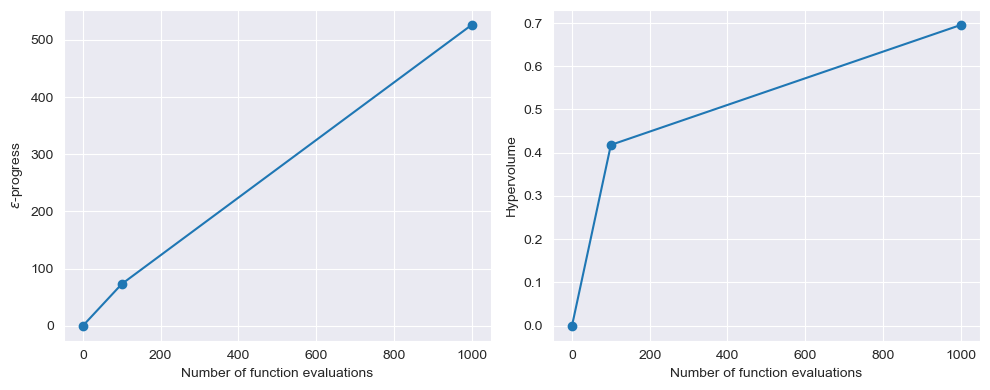

In [22]:
import matplotlib.pyplot as plt

# Extract from convergence DataFrame
epsilon_nfe = convergence["nfe"]
epsilon_values = convergence["epsilon_progress"]

# Extract from metrics DataFrame
hv_nfe = metrics["nfe"]
hv_values = metrics["hypervolume"]

# Plot
fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, figsize=(10, 4))

# ε-progress
ax1.plot(epsilon_nfe, epsilon_values, marker='o')
ax1.set_ylabel('$\\epsilon$-progress')

# Hypervolume
ax2.plot(hv_nfe, hv_values, marker='o')
ax2.set_ylabel('Hypervolume')

# Shared x-axis label
ax1.set_xlabel('Number of function evaluations')
ax2.set_xlabel('Number of function evaluations')

plt.tight_layout()
plt.show()